# <center>Instrumental variables and 2SLS</center>
### <center>Alfred Galichon (NYU)</center>
## <center>'math+econ+code' masterclass series: econometrics</center>
#### <center>With python code examples</center>

© 2018–2026 by Alfred Galichon. Past and present support from NSF grant DMS-1716489, ERC grant CoG-866274 are acknowledged, as well as inputs from contributors listed [here](http://www.math-econ-code.org/team).

**If you reuse material from this masterclass, please cite as:**<br>
Alfred Galichon, 'math+econ+code' masterclass series. https://www.math-econ-code.org/

### Learning objectives

* Recognize the three classical sources of endogeneity, omitted variables, simultaneity, measurement error, and demonstrate by Monte Carlo that OLS is inconsistent for the structural parameter under the first of them. (Measurement error gets the same treatment in Lecture 11; simultaneity is defined here, but full systems estimation is outside the scope of this series.)

* Define instrumental validity (relevance + exogeneity) and derive the just-identified IV estimator $\hat\beta_{\text{IV}} = (Z^\top X)^{-1}Z^\top y$, with its consistency under exogeneity.

* Generalize to two-stage least squares (2SLS) for over-identified models, recognize 2SLS as projection onto the column span of the instruments, and implement it from scratch.

* Compute the asymptotic variance of 2SLS, sandwich form again, under both homoskedasticity and heteroskedasticity, and produce the corresponding standard errors.

* Apply IV to the Mroz (1987) Mincer regression using parents' education as instruments for own education; carry out the **Sargan** test for over-identification (and distinguish it from Hansen's heteroskedasticity-robust $J$) and the Hausman test for endogeneity.

* Diagnose weak instruments via the first-stage $F$-statistic; demonstrate by simulation that 2SLS is biased and has heavy-tailed sampling distributions when instruments are weak.

### References

**[H]** Hansen, B. E. (2022). *Econometrics*. Princeton University Press. Chapters 11–12.

**[MHE]** Angrist, J. D., and Pischke, J.-S. (2009). *Mostly Harmless Econometrics*. Princeton University Press. Chapter 4.

**[SY]** Stock, J. H., and Yogo, M. (2005). 'Testing for Weak Instruments in Linear IV Regression'. In *Identification and Inference for Econometric Models*, Cambridge University Press.

**[Sa]** Sargan, J. D. (1958). 'The Estimation of Economic Relationships Using Instrumental Variables'. *Econometrica*, 26(3), 393–415.

**[Han]** Hansen, L. P. (1982). 'Large Sample Properties of Generalized Method of Moments Estimators'. *Econometrica*, 50(4), 1029–1054.

**[IA]** Imbens, G. W., and Angrist, J. D. (1994). 'Identification and Estimation of Local Average Treatment Effects'. *Econometrica*, 62(2), 467–475.

**[StS]** Staiger, D., and Stock, J. H. (1997). 'Instrumental Variables Regression with Weak Instruments'. *Econometrica*, 65(3), 557–586.

**[Hau]** Hausman, J. A. (1978). 'Specification Tests in Econometrics'. *Econometrica*, 46(6), 1251–1271.

**[M]** Mroz, T. A. (1987). 'The Sensitivity of an Empirical Model of Married Women's Hours of Work to Economic and Statistical Assumptions'. *Econometrica*, 55(4), 765–799.

# Motivation: structural parameters and selection

* In Lecture 3 we identified the OLS coefficient on `educ` in a Mincer regression as the *partial linear projection* of log-wage on education: an unambiguous statistical object, but not directly interpretable as the causal return to one additional year of schooling. The two diverge whenever education is correlated with unobserved determinants of wages, such as innate ability, family resources, or labor-market connections.

* The structural parameter we would like to know, "by how much would $i$'s wage rise if she received one additional year of schooling, holding everything else fixed?", is a counterfactual quantity: the causal effect in the potential-outcomes sense of the causal-inference lectures (`ci01`), with schooling as the treatment. Estimating it requires breaking the correlation between the regressor of interest and the error term, either by experimental variation or by a credible instrument: a variable that affects education but does not affect wages directly.

* This lecture develops the IV/2SLS toolkit on the Mroz (1987) sample, instrumenting own education by *parents'* education. This is a classic textbook example whose validity is debatable (parental education is plausibly correlated with child ability) but pedagogically clear; we treat the substantive validity question separately from the mechanical estimation question.

## Loading our libraries and data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from types import SimpleNamespace
import linearmodels.iv as iv

rng = np.random.default_rng(777)
plt.rcParams['figure.figsize'] = (8, 4.5)


In [2]:
url = 'https://vincentarelbundock.github.io/Rdatasets/csv/sampleSelection/Mroz87.csv'
try:
    mroz = pd.read_csv(url)                       # Rdatasets Mroz87 (needs a network)
except Exception:
    # Offline fallback: the identical Mroz (1987) data ships with the `wooldridge` package.
    import wooldridge
    mroz = (wooldridge.data('mroz')
            .rename(columns={'inlf': 'lfp', 'kidslt6': 'kids5', 'kidsge6': 'kids618'})
            .copy())
mroz_w = mroz.loc[mroz['lfp'] == 1].copy()
mroz_w['lwage'] = np.log(mroz_w['wage'])

# We need motheduc and fatheduc for the instruments
needed = ['lwage', 'educ', 'exper', 'motheduc', 'fatheduc']
print(f'I = {len(mroz_w)} working women')
print(f'Missing values:\n{mroz_w[needed].isna().sum()}')


I = 428 working women
Missing values:
lwage       0
educ        0
exper       0
motheduc    0
fatheduc    0
dtype: int64


# 1. The endogeneity problem

Consider the linear model $y_i = x_i^\top\beta + \varepsilon_i$ with $\mathbb{E}[x_i\varepsilon_i] \neq 0$. OLS targets the linear projection coefficient
$$
\hat\beta_{\text{OLS}}\xrightarrow{p}\beta + Q^{-1}\mathbb{E}[x_i\varepsilon_i] \;\neq\; \beta,
$$
which is *not* the structural parameter $\beta$. The orthogonality between regressors and errors that underpins OLS consistency (Lecture 4, (A3′)) is the substantive content of the exogeneity assumption.

Three canonical sources of endogeneity:

1. **Omitted variables.** $y_i = x_i^\top\beta + w_i\gamma + u_i$ with $\mathbb{E}[w_i\mid x_i]\neq 0$. If $w$ is unobserved, it is absorbed into $\varepsilon = w\gamma + u$, which is correlated with $x$.
2. **Simultaneity.** $y$ and $x$ are jointly determined by a system of equations. The canonical case is a **market**: quantity and price solve demand $q = \alpha_d - \beta_d\, p + \varepsilon_d$ and supply $q = \alpha_s + \beta_s\, p + \varepsilon_s$ *simultaneously*, so the equilibrium price $p = (\alpha_d - \alpha_s + \varepsilon_d - \varepsilon_s)/(\beta_d + \beta_s)$ is a function of *both* shocks, regressing $q$ on $p$ traces neither curve, because every demand shock that moves quantity moves price too. The IV cure previews itself: a shifter of *one* curve only, stormy seas cutting the catch in Graddy's (1995) Fulton fish market: moves the price along the *other* curve and so identifies it. (Full systems estimation is outside the scope of this series.)
3. **Measurement error.** $x$ is observed with classical noise $\tilde x = x + \nu$, so the regression of $y$ on $\tilde x$ has $\mathbb{E}[\tilde x\,(y - \tilde x^\top\beta)]\neq 0$.

## 1.1 Numerical demonstration: omitted-variable bias

We simulate a one-regressor model where the omitted variable $w$ is correlated with $x$, drives the bias in OLS, but is uncorrelated with the instrument $z$, so IV recovers $\beta$ while OLS does not.

In [3]:
def simulate_iv(I=2_000, β=0.5, γ=1.0, π=0.5, ρ_xw=0.5, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    z_i = rng.standard_normal(I)
    w_i = rng.standard_normal(I)                     # the omitted variable
    # x is generated with a contribution from z (instrument relevance)
    # and from w (the source of endogeneity, since w will go into ε)
    v_i = rng.standard_normal(I)                     # idiosyncratic shock to x
    x_i = π * z_i + ρ_xw * w_i + np.sqrt(1 - ρ_xw**2) * v_i
    u_i = rng.standard_normal(I)
    ε_i = γ * w_i + u_i                              # w enters ε via γ
    y_i = β * x_i + ε_i
    return x_i, y_i, z_i

rng_mc = np.random.default_rng(2026)
β_true = 0.5
R = 500
βols_r = np.empty(R)
βiv_r  = np.empty(R)

for r in range(R):
    x_i, y_i, z_i = simulate_iv(I=2_000, β=β_true, rng=rng_mc)
    βols_r[r] = (x_i @ y_i) / (x_i @ x_i)
    βiv_r[r]  = (z_i @ y_i) / (z_i @ x_i)

print(f'Truth:                  β = {β_true:.3f}')
print(f'OLS  mean(β̂) = {βols_r.mean():.4f}    std(β̂) = {βols_r.std():.4f}')
print(f'IV   mean(β̂) = {βiv_r.mean():.4f}    std(β̂) = {βiv_r.std():.4f}')


Truth:                  β = 0.500
OLS  mean(β̂) = 0.8998    std(β̂) = 0.0267
IV   mean(β̂) = 0.5014    std(β̂) = 0.0655


OLS systematically overstates $\beta$, by an amount that matches the analytical formula
$$
\mathrm{plim}\,\hat\beta_{\text{OLS}} = \beta + \gamma\,\frac{\mathrm{Cov}(x,w)}{\mathrm{Var}(x)} = 0.5 + 1.0\cdot 0.4 = 0.9,
$$
while IV centers exactly on the truth $\beta = 0.5$. The cost is roughly a doubling of standard deviation; IV is less efficient when the instrument is correlated only moderately with $x$. Note the word: IV *centres* on the truth here, and it is **consistent**, but it is not finite-sample unbiased. $\hat\beta_{\text{IV}}$ is a ratio of sample averages, and in the just-identified case it need not even possess a mean: the denominator $Z^\top X$ can be arbitrarily close to zero. With a strong instrument the sampling distribution is sufficiently concentrated that this feature is not apparent in the Monte Carlo mean; §6 shows what happens when the instrument is weak. We will return to this efficiency loss in §6 on weak instruments.

# 2. The instrumental variables estimator

## 2.1 Setup and definitions

Let $z_i\in\mathbb{R}^L$ be a vector of *instruments*. The IV identification conditions are:

**(IV-rel)** *Relevance*: $\mathbb{E}[z_i x_i^\top]$ has rank $K$.<br>
**(IV-exo)** *Exogeneity*: $\mathbb{E}[z_i\varepsilon_i] = 0$.

**A block notation used throughout.** Partition the regressors and the instruments as
$$
X = [\,X^{\mathrm{exo}},\ X^{\mathrm{endo}}\,],
\qquad
Z = [\,X^{\mathrm{exo}},\ Z^{\mathrm{exclu}}\,],
$$
where $X^{\mathrm{exo}}$ collects the exogenous regressors, the *controls*, **constant
included**, which appear in both matrices (they instrument themselves); $X^{\mathrm{endo}}$
collects the endogenous regressors, and $Z^{\mathrm{exclu}}$ the *excluded instruments*, which
appear only in $Z$. Counting columns, with $K_{\mathrm{exo}}$, $K_{\mathrm{endo}}$,
$L_{\mathrm{exclu}}$ the block widths:
$$
K = K_{\mathrm{exo}} + K_{\mathrm{endo}},
\qquad
L = K_{\mathrm{exo}} + L_{\mathrm{exclu}},
$$
so the order condition $L \ge K$ says exactly $L_{\mathrm{exclu}} \ge K_{\mathrm{endo}}$: **at
least one excluded instrument per endogenous regressor**. On Mroz (§4):
$X^{\mathrm{exo}} = (1, \texttt{exper}, \texttt{expersq})$, $X^{\mathrm{endo}} = \texttt{educ}$,
$Z^{\mathrm{exclu}} = (\texttt{motheduc}, \texttt{fatheduc})$, so $K = 4$, $L = 5$.

When $L = K$ (just-identified), the IV estimator is
$$
\hat\beta_{\text{IV}} := (Z^\top X)^{-1}\,Z^\top y.
$$
Note the asymmetry: the matrix being inverted is $Z^\top X$, not $X^\top X$. The regressors used to project $y$ are the instruments, but the parameter is the slope on $X$.

## 2.2 Consistency

Substituting $y = X\beta + \varepsilon$,
$$
\hat\beta_{\text{IV}} - \beta = (Z^\top X / I)^{-1}\,(Z^\top \varepsilon / I).
$$
By the LLN, $Z^\top X/I\xrightarrow{p}\mathbb{E}[z_i x_i^\top]$ (which is invertible by (IV-rel)) and $Z^\top\varepsilon/I\xrightarrow{p}\mathbb{E}[z_i\varepsilon_i] = 0$ by (IV-exo). The continuous mapping theorem gives $\hat\beta_{\text{IV}}\xrightarrow{p}\beta$.

---

**Theorem (Asymptotic normality of just-identified IV).** Under (IV-rel), (IV-exo), and standard moment conditions analogous to (A4′),
$$
\sqrt{I}\,(\hat\beta_{\text{IV}}-\beta)\xrightarrow{d}\mathcal{N}(0,V_{\text{IV}}),
$$
with $V_{\text{IV}} = \bigl(\mathbb{E}[z_i x_i^\top]\bigr)^{-1}\,\mathbb{E}[z_i z_i^\top\varepsilon_i^2]\,\bigl(\mathbb{E}[x_i z_i^\top]\bigr)^{-1}$.

---

The proof is the now-familiar CLT–CMT–Slutsky combination from Lecture 4, applied to the score $z_i\varepsilon_i$ rather than $x_i\varepsilon_i$. The asymptotic variance has the same sandwich shape, with the design matrix $\mathbb{E}[xx^\top]$ replaced by the cross-moment $\mathbb{E}[zx^\top]$.

# 3. Two-stage least squares for over-identified models

## 3.1 The estimator

When $L > K$, the system $Z^\top X\beta = Z^\top y$ is over-determined and *generally* has no exact solution (an over-determined system can happen to be exactly consistent in a particular sample, but won't be in general). The two-stage least squares (2SLS) estimator is the $(Z^\top Z)^{-1}$-**weighted** least-squares solution to these moment equations:
$$
\hat\beta_{\text{2SLS}} := \arg\min_\beta\;\bigl[Z^\top(y - X\beta)\bigr]^\top (Z^\top Z)^{-1}\bigl[Z^\top(y - X\beta)\bigr]
\;=\; \arg\min_\beta\;\bigl\lVert P_Z(y - X\beta)\bigr\rVert^2
\;=\; (X^\top P_Z X)^{-1}\,X^\top P_Z y,
$$
where $P_Z := Z(Z^\top Z)^{-1}Z^\top$. The weighting matters: plain *unweighted* least squares on the $L$ moment equations, $\min_\beta \lVert Z^\top(y - X\beta)\rVert^2$, is a different (and nonstandard) estimator. The $(Z^\top Z)^{-1}$ weight is what turns the objective into the squared norm of the *projected* residual $P_Z(y - X\beta)$, and it is the efficient choice under conditional homoskedasticity.
The matrix $P_Z$ is the projection onto the column space of $Z$. The estimator can be implemented in two stages, justifying the name:

* **First stage.** Project each column of $X$ onto the columns of $Z$: $\hat X := P_Z X$.
* **Second stage.** Run OLS of $y$ on $\hat X$. The coefficient is $(\hat X^\top \hat X)^{-1}\hat X^\top y = (X^\top P_Z X)^{-1}X^\top P_Z y$, since $\hat X^\top\hat X = X^\top P_Z X$ and $\hat X^\top y = X^\top P_Z y$.

When $L = K$, $Z^\top X$ is square and invertible, so the 2SLS formula collapses algebraically: $\hat\beta_{\text{2SLS}} = (X^\top P_Z X)^{-1} X^\top P_Z y = (Z^\top X)^{-1}(Z^\top Z)(X^\top Z)^{-1}\,(X^\top Z)(Z^\top Z)^{-1} Z^\top y = (Z^\top X)^{-1} Z^\top y$, the just-identified IV estimator. (Note $P_Z X \neq X$ in general, $X$ need not lie in the column span of $Z$, but the estimator still reduces because $Z^\top X$ is invertible.)

**In plain regression terms, what gets run on what.** On the Mroz application of §4:
*Stage 1* is an OLS regression of the endogenous regressor `educ` on **all** the exogenous
variables, the excluded instruments (`motheduc`, `fatheduc`) *and* the included controls
(constant, `exper`, `expersq`), keeping the fitted values $\widehat{\texttt{educ}}$. *Stage 2*
is an OLS regression of `lwage` on $\widehat{\texttt{educ}}$ and the same controls. Two details
carry all the danger. The controls must appear in **both** stages, omitting them from the first
stage is a classic implementation error, which the projection formula avoids automatically since
$Z$ contains the controls and $P_Z$ reproduces them exactly. And while the second-stage
*coefficients* reproduce 2SLS to machine precision, its printed *standard errors* are wrong: they
use the residuals $y - \hat X\hat\beta$ where inference needs $y - X\hat\beta$. IV software applies the correction
internally: one more reason not to run 2SLS as two literal OLS calls in applied work.

## 3.2 Asymptotic distribution

---

**Theorem.** Under (IV-rel), (IV-exo), and standard moment conditions,
$$
\sqrt{I}\,(\hat\beta_{\text{2SLS}}-\beta)\xrightarrow{d}\mathcal{N}(0,\,V_{\text{2SLS}}),
$$
$$
V_{\text{2SLS}} = (Q_{xz}\,Q_{zz}^{-1}\,Q_{zx})^{-1}\,Q_{xz}\,Q_{zz}^{-1}\,\Omega_{zz}\,Q_{zz}^{-1}\,Q_{zx}\,(Q_{xz}\,Q_{zz}^{-1}\,Q_{zx})^{-1},
$$
with $Q_{xz} := \mathbb{E}[x_i z_i^\top]$, $Q_{zz} := \mathbb{E}[z_i z_i^\top]$, $\Omega_{zz} := \mathbb{E}[z_i z_i^\top\varepsilon_i^2]$.

---

Under conditional homoskedasticity ($\mathbb{E}[\varepsilon_i^2\mid z_i] = \sigma^2$), $\Omega_{zz} = \sigma^2 Q_{zz}$ and the variance simplifies to $\sigma^2(Q_{xz}Q_{zz}^{-1}Q_{zx})^{-1}$. The corresponding sample analogs give the classical and heteroskedasticity-robust 2SLS standard errors.

## 3.3 DIY implementation

In [4]:
def tsls(X_i_k, y_i, Z_i_l):
    # Two-stage least squares with classical and HC0 standard errors.
    #   X_i_k : (I, K) regressors (endogenous + exogenous)
    #   y_i   : (I,)   outcome
    #   Z_i_l : (I, L) instruments (must include the exogenous part of X)
    I, K = X_i_k.shape
    ZtZinv_l_l = np.linalg.inv(Z_i_l.T @ Z_i_l)
    PZX_i_k    = Z_i_l @ (ZtZinv_l_l @ (Z_i_l.T @ X_i_k))       # = P_Z X
    XPZX_k_k   = X_i_k.T @ PZX_i_k
    XPZy_k     = X_i_k.T @ (Z_i_l @ (ZtZinv_l_l @ (Z_i_l.T @ y_i)))
    β_k        = np.linalg.solve(XPZX_k_k, XPZy_k)
    εhat_i     = y_i - X_i_k @ β_k
    XPZXinv_k_k = np.linalg.inv(XPZX_k_k)

    # Classical (homoskedastic) variance
    σ2 = (εhat_i @ εhat_i) / (I - K)
    Vcl_k_k = σ2 * XPZXinv_k_k

    # HC0 robust variance (sandwich form)
    Ω_k_k = (PZX_i_k * (εhat_i ** 2)[:, None]).T @ PZX_i_k
    Vrob_k_k = XPZXinv_k_k @ Ω_k_k @ XPZXinv_k_k

    return SimpleNamespace(
        β_k=β_k, εhat_i=εhat_i,
        Vcl_k_k=Vcl_k_k, secl_k=np.sqrt(np.diag(Vcl_k_k)),
        Vrob_k_k=Vrob_k_k, serob_k=np.sqrt(np.diag(Vrob_k_k)),
        I=I, K=K, L=Z_i_l.shape[1],
    )


In [5]:
# Just-identified IV reduces to 2SLS when L = K
def iv_just(X_i_k, y_i, Z_i_l):
    I, K = X_i_k.shape
    β_k = np.linalg.solve(Z_i_l.T @ X_i_k, Z_i_l.T @ y_i)
    εhat_i = y_i - X_i_k @ β_k
    σ2 = (εhat_i @ εhat_i) / (I - K)
    ZtXinv_k_l = np.linalg.inv(Z_i_l.T @ X_i_k)
    Vcl_k_k = σ2 * ZtXinv_k_l @ (Z_i_l.T @ Z_i_l) @ ZtXinv_k_l.T

    # HC0 sandwich, the just-identified analogue of the 2SLS one below:
    #   V = (Z'X)^{-1} [ Σ_i ε̂_i² z_i z_i' ] (X'Z)^{-1}
    Ω_l_l = (Z_i_l * (εhat_i ** 2)[:, None]).T @ Z_i_l
    Vrob_k_k = ZtXinv_k_l @ Ω_l_l @ ZtXinv_k_l.T

    return SimpleNamespace(β_k=β_k, εhat_i=εhat_i,
                           Vcl_k_k=Vcl_k_k, secl_k=np.sqrt(np.diag(Vcl_k_k)),
                           Vrob_k_k=Vrob_k_k, serob_k=np.sqrt(np.diag(Vrob_k_k)),
                           I=I, K=K)


# 4. Application: returns to schooling on Mroz (1987)

We instrument own education in the Mincer regression by parents' education. Two specifications:

* **Just-identified IV.** Use only `motheduc` as instrument for `educ`.
* **Over-identified 2SLS.** Use both `motheduc` and `fatheduc`.

The exogenous controls (`exper`, `exper²`, the intercept) appear in both $X$ and $Z$: exogenous regressors are their own instruments.

## 4.1 Set-up

In [6]:
y_i = mroz_w['lwage'].values
I = len(y_i)

# Endogenous regressor + exogenous controls
X_i_k = np.column_stack([
    np.ones(I),
    mroz_w['educ'].values,                       # ENDOGENOUS
    mroz_w['exper'].values,
    mroz_w['exper'].values ** 2,
])
xnames = ['const', 'educ', 'exper', 'exper^2']

# Just-identified instruments: replace educ by motheduc
Zjust_i_l = np.column_stack([
    np.ones(I),
    mroz_w['motheduc'].values,
    mroz_w['exper'].values,
    mroz_w['exper'].values ** 2,
])

# Over-identified instruments: replace educ by motheduc + fatheduc
Zover_i_l = np.column_stack([
    np.ones(I),
    mroz_w['motheduc'].values,
    mroz_w['fatheduc'].values,
    mroz_w['exper'].values,
    mroz_w['exper'].values ** 2,
])
print(f'X_i_k has shape {X_i_k.shape}; Zjust_i_l has shape {Zjust_i_l.shape}; Zover_i_l has shape {Zover_i_l.shape}')


X_i_k has shape (428, 4); Zjust_i_l has shape (428, 4); Zover_i_l has shape (428, 5)


## 4.2 Three estimators side by side

In [7]:
# OLS
βols_k = np.linalg.solve(X_i_k.T @ X_i_k, X_i_k.T @ y_i)
εhatols_i = y_i - X_i_k @ βols_k
σ2_ols = (εhatols_i @ εhatols_i) / (I - X_i_k.shape[1])
seols_k = np.sqrt(np.diag(σ2_ols * np.linalg.inv(X_i_k.T @ X_i_k)))

# Just-identified IV (Zjust_i_l is square at L = K = 4)
fit_iv = iv_just(X_i_k, y_i, Zjust_i_l)

# Over-identified 2SLS
fit_2sls = tsls(X_i_k, y_i, Zover_i_l)

# Robust standard errors are the ones to lead with: nothing in §1-§3 assumed homoskedasticity,
# and §5.1 will show the Mroz residuals are not obviously homoskedastic either. The classical
# ones are kept alongside so the two can be compared rather than silently swapped.
seolsrob_k = np.sqrt(np.diag(
    np.linalg.inv(X_i_k.T @ X_i_k)
    @ ((X_i_k * (εhatols_i ** 2)[:, None]).T @ X_i_k)
    @ np.linalg.inv(X_i_k.T @ X_i_k)))

print('standard errors: HC0 robust first, classical homoskedastic in brackets\n')
print(f"{'name':<10s}{'OLS':>26s}{'IV (motheduc)':>26s}{'2SLS (mother+father)':>28s}")
for k, name in enumerate(xnames):
    o  = f'{βols_k[k]:>8.4f} {seolsrob_k[k]:.4f} [{seols_k[k]:.4f}]'
    i_ = f'{fit_iv.β_k[k]:>8.4f} {fit_iv.serob_k[k]:.4f} [{fit_iv.secl_k[k]:.4f}]'
    s  = f'{fit_2sls.β_k[k]:>8.4f} {fit_2sls.serob_k[k]:.4f} [{fit_2sls.secl_k[k]:.4f}]'
    print(f'{name:<10s}{o:>26s}{i_:>26s}{s:>28s}')

print(f'\nratio robust/classical on educ:  OLS {seolsrob_k[1]/seols_k[1]:.3f}   '
      f'IV {fit_iv.serob_k[1]/fit_iv.secl_k[1]:.3f}   '
      f'2SLS {fit_2sls.serob_k[1]/fit_2sls.secl_k[1]:.3f}')


standard errors: HC0 robust first, classical homoskedastic in brackets

name                             OLS             IV (motheduc)        2SLS (mother+father)
const        -0.5220 0.2007 [0.1986]    0.1982 0.4869 [0.4729]      0.0481 0.4278 [0.4003]
educ          0.1075 0.0132 [0.0141]    0.0493 0.0379 [0.0374]      0.0614 0.0332 [0.0314]
exper         0.0416 0.0152 [0.0132]    0.0449 0.0155 [0.0136]      0.0442 0.0155 [0.0134]
exper^2      -0.0008 0.0004 [0.0004]   -0.0009 0.0004 [0.0004]     -0.0009 0.0004 [0.0004]

ratio robust/classical on educ:  OLS 0.930   IV 1.011   2SLS 1.056


The OLS estimate of the return to schooling is $0.107$ (10.7% per year). Both IV specifications produce smaller estimates, about 0.049 (just-identified) and 0.061 (2SLS), at the cost of standard errors roughly 2.5–3× larger. If parents' education is a *valid* instrument (i.e., it affects log-wages only through its effect on own education), then OLS overstates the return to schooling by about 4–6 percentage points. Positive ability selection, the cross-sectional OLS coefficient bundling the causal return with the wage payoff to unobserved ability, is *one* explanation consistent with this pattern, not the identified one. The gap could equally reflect a failure of the exclusion restriction (parents' education moving wages through family background rather than schooling alone), or the fact that under *heterogeneous* returns OLS and IV estimate differently weighted averages of individual returns, IV loads on the units the instruments actually move, so the two numbers can differ even with no selection bias at all.

## 4.3 Comparison with `linearmodels.IV2SLS`

In [8]:
# linearmodels expects a specific input layout; the API distinguishes
# 'exogenous' regressors, 'endogenous' regressors, and 'instruments'.
data = mroz_w.copy()
data['expersq'] = data['exper'] ** 2

mod_2sls = iv.IV2SLS.from_formula(
    'lwage ~ 1 + exper + expersq + [educ ~ motheduc + fatheduc]',
    data=data,
)
res_2sls = mod_2sls.fit(cov_type='unadjusted', debiased=True)   # I-K denominator, matching the DIY s.e.

# Order coefficients to match our DIY xnames (linearmodels uses 'Intercept')
lm_index = ['Intercept', 'educ', 'exper', 'expersq']
sm_β_k  = res_2sls.params.reindex(lm_index).values
sm_se_k = res_2sls.std_errors.reindex(lm_index).values

print(f"{'name':<10s}{'DIY 2SLS β̂':>14s}{'lm β̂':>12s}{'DIY se':>12s}{'lm se':>12s}")
for name, b1, b2, s1, s2 in zip(xnames, fit_2sls.β_k, sm_β_k, fit_2sls.secl_k, sm_se_k):
    print(f'{name:<10s}{b1:>14.6f}{b2:>12.6f}{s1:>12.6f}{s2:>12.6f}')
print(f'\nmax |β̂_DIY - β̂_lm|  = {np.max(np.abs(fit_2sls.β_k - sm_β_k)):.2e}')
print(f'max |se_DIY - se_lm| = {np.max(np.abs(fit_2sls.secl_k - sm_se_k)):.2e}')


name         DIY 2SLS β̂       lm β̂      DIY se       lm se
const           0.048100    0.048100    0.400328    0.400328
educ            0.061397    0.061397    0.031437    0.031437
exper           0.044170    0.044170    0.013432    0.013432
exper^2        -0.000899   -0.000899    0.000402    0.000402

max |β̂_DIY - β̂_lm|  = 1.61e-13
max |se_DIY - se_lm| = 4.95e-14


# 5. Diagnostic tests

## 5.1 The Sargan test for over-identification

Let $\hat\varepsilon := y-X\hat\beta_{\text{2SLS}}$ denote the **structural 2SLS residuals**, computed using the actual regressors $X$, not the first-stage fitted values $\hat X$. When $L > K$ (over-identified case), the model imposes $L - K$ over-identifying restrictions ($L - K = L_{\mathrm{exclu}} -
K_{\mathrm{endo}}$ in the §2.1 partition: the *surplus* excluded instruments): with all instruments valid, $\hat\varepsilon$ should be asymptotically orthogonal to *all* of $Z$, not just to a $K$-dimensional sub-space. The Sargan statistic
$$
J := \hat\varepsilon^\top P_Z\hat\varepsilon\,/\,\hat\sigma^2,
\qquad
\hat\sigma^2 = \hat\varepsilon^\top\hat\varepsilon/I,
$$
is asymptotically $\chi^2_{L-K}$ under the null that the $L-K$ **excess orthogonality restrictions are jointly compatible** with the model. This interpretation is conditional on a valid set of instruments identifying $\beta$ and on a correctly specified structural equation. Rejection therefore flags at least one invalid instrument or model misspecification, but does not reveal which restriction failed. Non-rejection does not establish instrument validity: the test may have little power, and invalid instruments can be mutually compatible.

**Scope.** The Sargan statistic above uses a single variance estimate $\hat\sigma^2$ and is valid only under **homoskedasticity**. Its heteroskedasticity-robust counterpart, Hansen's $J$ test, is derived from GMM and was developed in **Lecture 9, §5**.

**Intuition.** Exogeneity is fundamentally
untestable instrument by instrument. But with $L > K$, more instruments than the model needs )
the model is forced into a *falsifiable* claim: every valid instrument should be uncorrelated with
the residuals. The test does literally that: estimate by 2SLS, take the residuals
$\hat\varepsilon$, regress them on *all* of $Z$, and ask whether the instruments explain any of the
residual variation. The statistic equals $I \cdot R^2$ from that auxiliary regression, identical
to the projection form above (both give $J = 0.378$ here), and is $\chi^2_{L-K}$ under the null:
one degree of freedom per *surplus* instrument. A small $J$ (large $p$) means the over-identifying
restrictions pass; a large $J$ means at least one instrument is contaminated, correlated with
the error, i.e.\ moving the outcome through some channel other than $X$. (Hansen's $J$, above, is
the same idea made robust to heteroskedasticity, in GMM form.) Two caveats to keep. It is a
**joint** test: rejection says something is wrong *somewhere*, never which instrument is guilty )
and instruments that are invalid *in the same direction* can agree with one another, so the test
detects mutual inconsistency among instruments, never shared invalidity. And the test exists *only* under over-identification: at $L = K$
the 2SLS residuals are orthogonal to $Z$ by construction, and there is nothing to test.

## 5.2 Hausman test for endogeneity

The Hausman test compares OLS and 2SLS:

* Under the null $H_0:$ all regressors are exogenous, OLS is consistent and efficient; 2SLS is consistent but inefficient.
* Under the alternative $H_1:$ some regressors are endogenous, only 2SLS is consistent.

The test statistic, with the same logic as the FE-vs-RE Hausman of Lecture 5, §6.4, is
$$
H = (\hat\beta_{\text{2SLS}} - \hat\beta_{\text{OLS}})^\top\bigl[V_{\text{2SLS}} - V_{\text{OLS}}\bigr]^{-1}(\hat\beta_{\text{2SLS}} - \hat\beta_{\text{OLS}})\xrightarrow{d}\chi^2_{Q},
$$
where $Q$ is the number of suspected endogenous regressors.

**A convention note, why no $\sqrt I$.** Here $V_{\text{OLS}}$ and $V_{\text{2SLS}}$ are the
estimated covariance matrices of the estimators *themselves*, the objects a regression printout
reports, e.g.\ $\hat\sigma^2 (X^\top X)^{-1}$, and these already carry the $1/I$, since
$X^\top X \approx I\,\mathbb{E}[x_i x_i^\top]$. Asymptotic theorems are instead stated for
$\sqrt I\,(\hat\beta - \beta)$ with $O(1)$ variance matrices; in that convention the same statistic
reads $I\,(\hat\beta_{\text{2SLS}} - \hat\beta_{\text{OLS}})^\top V_{\text{diff}}^{-1}
(\hat\beta_{\text{2SLS}} - \hat\beta_{\text{OLS}})$. The two forms are numerically identical )
the $I$ lives either outside the quadratic form or inside the inverted matrix, and this course's
implementations always use the finite-sample convention, here and in every Wald statistic.

Two caveats are important. First, the efficiency ranking that powers the statistic, OLS efficient under $H_0$, is a **homoskedasticity** result, and the whole comparison presumes the instruments are valid: with an invalid instrument, 2SLS is inconsistent under *both* hypotheses and the test compares two wrong answers. Second, a failure to reject is **not** affirmative evidence that OLS is exogenous: the variance of the OLS–2SLS difference is large exactly when the instruments are not strong, so the test can have little power: “no rejection” may only mean “no precision.”

In [9]:
# Sargan J-statistic
εhat_i = fit_2sls.εhat_i
σ2_hat = (εhat_i @ εhat_i) / I
PZεhat_i = Zover_i_l @ np.linalg.solve(Zover_i_l.T @ Zover_i_l, Zover_i_l.T @ εhat_i)
J = (εhat_i @ PZεhat_i) / σ2_hat
df_J = Zover_i_l.shape[1] - X_i_k.shape[1]    # L - K = 5 - 4 = 1
p_J = 1 - stats.chi2.cdf(J, df=df_J)
print(f'Sargan J-statistic    = {J:.4f}')
print(f'χ²_{df_J} 95% critical = {stats.chi2.ppf(0.95, df_J):.4f}')
print(f'p-value               = {p_J:.4f}')

# Hausman test on the educ coefficient (the only suspected endogenous regressor)
k_educ = 1
β_diff = fit_2sls.β_k[k_educ] - βols_k[k_educ]
Vols_k_k = σ2_ols * np.linalg.inv(X_i_k.T @ X_i_k)
V_diff = fit_2sls.Vcl_k_k[k_educ, k_educ] - Vols_k_k[k_educ, k_educ]
if V_diff > 0:
    H = β_diff ** 2 / V_diff
    p_H = 1 - stats.chi2.cdf(H, df=1)
    print(f'\nHausman statistic     = {H:.4f}  (df = 1)')
    print(f'p-value               = {p_H:.4f}')
else:
    print(f'\nV_diff = {V_diff:.2e} not positive — Hausman test inconclusive')


Sargan J-statistic    = 0.3781
χ²_1 95% critical = 3.8415
p-value               = 0.5386

Hausman statistic     = 2.6957  (df = 1)
p-value               = 0.1006


The Sargan test does not reject the null of valid over-identifying restrictions ($p\approx 0.54$), but the conclusion is only meaningful conditional on at least one of the two instruments being valid. The Hausman test marginally fails to reject exogeneity ($p\approx 0.10$); the OLS and 2SLS coefficients on `educ` are visibly different but the standard errors of the difference are large enough to dilute the signal. In practice, applied researchers report both OLS and IV with appropriate caveats.

# 6. Weak instruments

When the instrument is weakly correlated with $X$, i.e., when the first-stage coefficients are close to zero, 2SLS exhibits two pathologies:

1. **Finite-sample bias toward OLS.** For any *fixed* $\pi\neq 0$, 2SLS is consistent: weakness is not a violation of the asymptotic theory of §3. The problem is that the asymptotics are a poor description of the sample at hand: in finite samples $\hat\beta_{\text{2SLS}}$ is biased in the direction of $\hat\beta_{\text{OLS}}$, with a relative bias of order $1/\mathbb{E}[F]$ (Staiger–Stock, 1997). The *weak-instrument asymptotics* that formalise this let $\pi$ shrink with the sample size, $\pi = c/\sqrt{I}$, so that the concentration parameter stays fixed and the bias does not vanish. Under that sequence 2SLS is genuinely inconsistent.
2. **Heavy-tailed sampling distribution.** The Gaussian approximation breaks down: the actual sampling distribution is skewed and heavy-tailed (in the just-identified case its mean does not even exist), and conventional confidence intervals badly under-cover.

**Where the pull toward OLS comes from, in two lines.** In the just-identified one-regressor model
with first stage $x = \pi z + v$, write $A := z^\top\varepsilon/I$ and $B := z^\top v/I$, so that
$\hat\beta_{\mathrm{IV}} - \beta = A/(\pi\,\overline{z^2} + B)$. The two noises are built from the
*same* draws of $z$, and $\mathrm{Cov}(A,B) \approx \mathbb{E}[z^2]\,\sigma_{v\varepsilon}/I$ (
their correlation *is* the endogeneity. Conditioning on the denominator (joint normality),
$\mathbb{E}[A \mid B] = (\sigma_{v\varepsilon}/\sigma_v^2)\,B$, so in the weak limit $\pi \to 0$:
$$
\frac{A}{B} \;=\; \underbrace{\frac{\sigma_{v\varepsilon}}{\sigma_v^2}}_{\text{center}}
\;+\; \underbrace{\frac{(\text{noise} \perp B)}{B}}_{\text{symmetric, heavy-tailed}},
$$
and since $x \approx v$ when $\pi \approx 0$, the center $\sigma_{v\varepsilon}/\sigma_v^2 =
\mathbb{E}[x\varepsilon]/\mathbb{E}[x^2]$ is exactly the **OLS bias**. An irrelevant instrument does
not produce a truth-centered estimator with wide error bars; it produces an *OLS-centered* one with
wide error bars, the only systematic signal left in the ratio is the very contamination OLS
suffers from. Strong instruments ($\pi\,\overline{z^2}$ dominating $B$) restore the symmetric,
$\beta$-centered case, and the relative bias of order $1/\mathbb{E}[F]$ interpolates between the two
extremes.

**The $F>10$ rule.** The familiar threshold is the **Staiger–Stock (1997)** rule of thumb. Stock and Yogo (2005) made it precise, but what they provide is a *table* of critical values that depends on the number of instruments and on which distortion one is willing to tolerate: 10\% relative bias, or 10/15/20/25\% size distortion of the nominal-5\% Wald test. For one endogenous regressor and a handful of instruments the 10\%-relative-bias values sit near 10, which is where the folk rule comes from; the size-distortion values are much larger (above 16 for a single instrument at 10\%). More recent work (Montiel Olea–Pflueger, 2013; Lee et al., 2022) argues that $F>10$ is far too permissive when the goal is valid inference rather than bias control. Treat 10 as a rough diagnostic, not a certificate.

We illustrate by simulation, varying the strength parameter $\pi$ across a grid.

## 6.1 First-stage $F$ on Mroz

Two cautions before reading the number. First, the statistic below is the **conventional**
homoskedastic $F$; the robust Wald version of the same exclusion restriction is reported
beside it, and the two need not agree when the first stage is heteroskedastic. Second, the
familiar $F>10$ threshold of Staiger and Stock (1997) is a rule of thumb calibrated for a
*single* endogenous regressor under *homoskedastic* errors, targeting a specific bound on
2SLS bias relative to OLS. It is not a general certificate: with several endogenous
regressors the relevant object is the Cragg–Donald or Kleibergen–Paap statistic compared to
Stock–Yogo critical values, under heteroskedasticity the effective threshold is higher (Montiel
Olea and Pflueger 2013 argue for substantially higher), and clearing 10 does not license
ignoring weak-instrument concerns altogether. Passing the rule is best read as "not obviously
disqualifying" rather than "strong".

Compute the first-stage regression of $X^{\mathrm{endo}} = {}$`educ` on all of
$Z = [X^{\mathrm{exo}}, Z^{\mathrm{exclu}}]$, and read the $F$-statistic for the joint
significance of the excluded block $Z^{\mathrm{exclu}} = ($`motheduc`, `fatheduc`$)$.

In [10]:
# First-stage regression: educ on Zover_i_l (incl. constant, exper, exper^2)
educ_i = mroz_w['educ'].values
βfs_l = np.linalg.solve(Zover_i_l.T @ Zover_i_l, Zover_i_l.T @ educ_i)
educhat_i = Zover_i_l @ βfs_l
ssr_full = ((educ_i - educhat_i) ** 2).sum()

# Restricted: drop motheduc and fatheduc (positions 1 and 2 in Zover_i_l)
Zrestr_i_l = Zover_i_l[:, [0, 3, 4]]
βfsr_l = np.linalg.solve(Zrestr_i_l.T @ Zrestr_i_l, Zrestr_i_l.T @ educ_i)
ssr_restricted = ((educ_i - Zrestr_i_l @ βfsr_l) ** 2).sum()

Q = 2  # number of excluded instruments
F_first_stage = ((ssr_restricted - ssr_full) / Q) / (ssr_full / (I - Zover_i_l.shape[1]))
p_F = 1 - stats.f.cdf(F_first_stage, Q, I - Zover_i_l.shape[1])
print(f'Conventional (homoskedastic) first-stage F               = {F_first_stage:.3f}')
print(f'p-value                                                  = {p_F:.4e}')

# The same joint exclusion restriction, tested with an HC0 covariance. This does not assume
# homoskedastic first-stage errors, and it is the statistic the F > 10 rule was NOT calibrated on.
εfs_i = educ_i - educhat_i
ZtZinv = np.linalg.inv(Zover_i_l.T @ Zover_i_l)
Vfs_l_l = ZtZinv @ ((Zover_i_l * (εfs_i ** 2)[:, None]).T @ Zover_i_l) @ ZtZinv
R_q_l = np.zeros((Q, Zover_i_l.shape[1]))
R_q_l[0, 1] = R_q_l[1, 2] = 1.0                     # motheduc, fatheduc
dev_q = R_q_l @ βfs_l
W_rob = dev_q @ np.linalg.solve(R_q_l @ Vfs_l_l @ R_q_l.T, dev_q)
print(f'Heteroskedasticity-robust Wald / Q (same restriction)    = {W_rob / Q:.3f}')
print(f'   robust p-value                                        = '
      f'{1 - stats.chi2.cdf(W_rob, Q):.4e}')

print(f'\nStaiger–Stock rule of thumb (F > 10)?                    = '
      f'{"Yes" if F_first_stage > 10 else "No"}')
print('   — but see the caveats in the text: the rule is calibrated for the conventional')
print('     homoskedastic F with a single endogenous regressor, not for the robust statistic.')


Conventional (homoskedastic) first-stage F               = 55.400
p-value                                                  = 1.1102e-16
Heteroskedasticity-robust Wald / Q (same restriction)    = 50.112
   robust p-value                                        = 0.0000e+00

Staiger–Stock rule of thumb (F > 10)?                    = Yes
   — but see the caveats in the text: the rule is calibrated for the conventional
     homoskedastic F with a single endogenous regressor, not for the robust statistic.


The first-stage $F$ is far above the conventional benchmark of 10: in fact above the stricter Stock–Yogo size-distortion values as well. Parents' education is a *strong* predictor of own education in this sample, so whatever objections one might have to the IV estimates above (and the exclusion restriction is a serious one), weak instruments is not among them.

## 6.2 Monte Carlo demonstration

We simulate the IV setup of §1 across a grid of instrument strengths $\pi$ from very weak (0.02) to strong (0.5), and plot the empirical sampling distribution of the 2SLS estimator on a single chart.

In [11]:
rng_mc = np.random.default_rng(2026)
R = 2_000
I_sim = 500
β_true = 0.5
π_s = [0.02, 0.05, 0.1, 0.3, 0.5]     # grid of instrument strengths, s in [S]

results = {}
F_avg = {}
for π in π_s:
    β_r = np.empty(R)
    F_r = np.empty(R)
    for r in range(R):
        x_i, ysim_i, z_i = simulate_iv(I=I_sim, β=β_true, π=π, rng=rng_mc)
        # 2SLS slope (one regressor, one instrument: just-identified IV)
        β_r[r] = (z_i @ ysim_i) / (z_i @ x_i)
        # First-stage F = t² for the slope of x on z
        z2 = z_i @ z_i
        π_hat = (z_i @ x_i) / z2
        ehat_i = x_i - π_hat * z_i
        σ2_e = (ehat_i @ ehat_i) / (I_sim - 1)
        se_π = np.sqrt(σ2_e / z2)
        F_r[r] = (π_hat / se_π) ** 2
    results[π] = β_r
    F_avg[π] = F_r.mean()

# The weak-instrument distributions have very heavy tails; the plot shows only the window
# [-2, 3] (out-of-window draws are EXCLUDED, not piled at the border) and each density is
# over the displayed window only; the excluded shares are printed first.
for π in π_s:
    out = np.mean((results[π] < -2) | (results[π] > 3))
    print(f'π = {π:>4}:  mean F = {F_avg[π]:7.1f},  share of draws outside the [-2, 3] '
          f'plotting window = {out:6.2%}')


π = 0.02:  mean F =     1.3,  share of draws outside the [-2, 3] plotting window = 27.45%
π = 0.05:  mean F =     2.2,  share of draws outside the [-2, 3] plotting window = 18.20%
π =  0.1:  mean F =     6.3,  share of draws outside the [-2, 3] plotting window =  3.90%
π =  0.3:  mean F =    46.0,  share of draws outside the [-2, 3] plotting window =  0.00%
π =  0.5:  mean F =   126.9,  share of draws outside the [-2, 3] plotting window =  0.00%


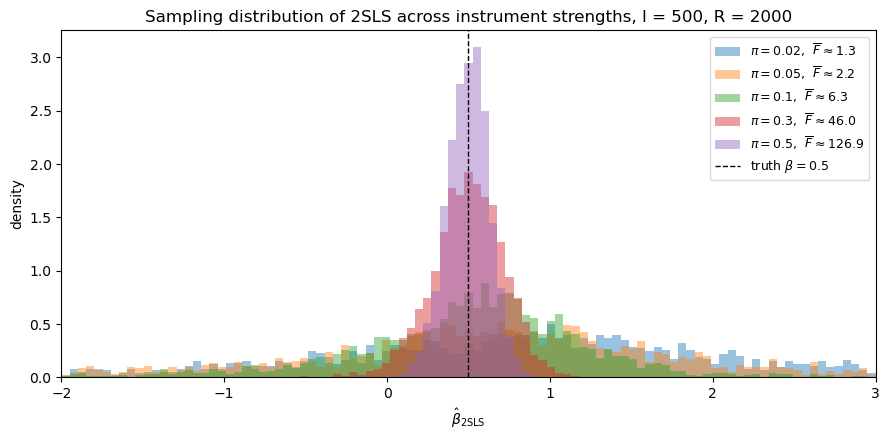

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
bins = np.linspace(-2, 3, 100)
for π, β_r in results.items():
    ax.hist(β_r[(β_r >= -2) & (β_r <= 3)], bins=bins, density=True, alpha=0.45,
            label=fr'$\pi = {π}$,  $\overline{{F}} \approx {F_avg[π]:.1f}$')
ax.axvline(β_true, color='k', ls='--', lw=1.0, label=fr'truth $\beta = {β_true}$')
ax.set_xlim(-2, 3)
ax.set_xlabel(r'$\hat\beta_{\rm 2SLS}$')
ax.set_ylabel('density')
ax.set_title(f'Sampling distribution of 2SLS across instrument strengths, I = {I_sim}, R = {R}')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()


The strong-instrument case ($\pi=0.5$) produces a tight, approximately symmetric Gaussian sampling distribution centered on the true $\beta$. As $\pi$ shrinks toward zero, the distribution becomes increasingly heavy-tailed, asymmetric, and pulled toward the OLS estimand, which under our DGP is $\beta+\gamma\rho_{xw}/(1+\pi^2)$, since the instrument's contribution $\pi^2$ enters $\operatorname{Var}(x)$: it equals $0.9$ at $\pi=0.5$ and rises toward $1.0$ as $\pi\to 0$, so it is effectively $1.0$ for the weak designs. At $\pi=0.02$ the estimator is essentially uninformative: the spread is enormous and its centre is close to that limiting OLS bias.

Two cautions about reading the figure. First, the histogram shows only the window $[-2,3]$: for the weakest designs a non-trivial share of draws falls outside it and is **excluded** from the plot (the shares are printed above), so the plotted densities describe the central part of each distribution and are silent about the tails. Second, the picture is a *smooth* deterioration, not a phase transition. There is no sharp line at $F=10$ separating "trustworthy" from "untrustworthy"; the quality of the normal approximation degrades continuously as the concentration parameter falls, and any threshold, 10, or the larger Stock–Yogo size-distortion values, is a convention marking how much distortion one is prepared to tolerate.

# Looking ahead

The IV/2SLS estimator and its inference machinery connect outward in three directions:

* **Generalized Method of Moments (Lecture 9).** 2SLS is the GMM estimator that uses the moment condition $\mathbb{E}[z_i\varepsilon_i] = 0$ with the weight matrix $(Z^\top Z)^{-1}$. Other choices of weight matrix produce different estimators with the same probability limit but different asymptotic variance, and the *efficient* choice yields, in the over-identified case, an asymptotic variance smaller than 2SLS's.

* **Difference-in-differences and event studies (`ci02`).** A natural-experiment-style instrument induced by a policy reform, eligibility, a draft lottery, a regression discontinuity cutoff, fits the IV framework directly; the resulting estimator is called LATE (Local Average Treatment Effect) under the monotonicity assumption of Imbens and Angrist (1994): the estimand is the average effect *for compliers*, not for the whole population.

* **Weak-instrument-robust inference.** When the first-stage $F$ is low, alternatives to the conventional Wald test, Anderson–Rubin, conditional likelihood ratio, weak-instrument-robust confidence intervals, are needed. This series does not develop them; **[SY]** and **[StS]** are the entry points.

The next lecture (**Lecture 11, measurement error and specification**) returns to the third source of endogeneity listed in §1. A mismeasured regressor is an endogeneity problem with a known sign, attenuation toward zero, and instrumenting it is the same fix applied here, now with a second measurement in the role of $z$. Lecture 11 also supplies the specification tests that belong beside the diagnostics of §5: RESET for functional form, and Durbin–Wu–Hausman in its regression form.